In [1]:
import zipfile
from pathlib import Path


zip_file = Path("plantdisease.zip")

output_folder = Path("plantdisease")



print("📂 Unzipping dataset files...")



with zipfile.ZipFile(zip_file, "r") as zip_ref:

    zip_ref.extractall(output_folder)



print("🎉 Success! Your files are ready.")

📂 Unzipping dataset files...
🎉 Success! Your files are ready.


In [2]:
from pathlib import Path

print("Current notebook location:")
print(Path.cwd())

print("\nFolders/files here:")
for item in Path.cwd().iterdir():
    print(item)

Current notebook location:
c:\Users\HP\Downloads\Plant Dieases Classification Model

Folders/files here:
c:\Users\HP\Downloads\Plant Dieases Classification Model\.myvenv
c:\Users\HP\Downloads\Plant Dieases Classification Model\02_train_mobilenet.ipynb
c:\Users\HP\Downloads\Plant Dieases Classification Model\data
c:\Users\HP\Downloads\Plant Dieases Classification Model\kaggle.json
c:\Users\HP\Downloads\Plant Dieases Classification Model\notebooks
c:\Users\HP\Downloads\Plant Dieases Classification Model\plantdisease
c:\Users\HP\Downloads\Plant Dieases Classification Model\plantdisease.zip
c:\Users\HP\Downloads\Plant Dieases Classification Model\requirements.txt


In [ ]:
"data augumentation is when you maipulate image to create more images from the original image to increase the dataset size and make the model more robust"

from pathlib import Path

print("\nSearching for PlantVillage folders...")

for path in Path(".").rglob("Potato___Early_blight"):
    print(path)


Searching for PlantVillage folders...
data\kaggle_plantvillage\PlantVillage\Potato___Early_blight


LOADING POTATO DATASET (3 CLASSES)

📂 Potato___Early_blight: 1000 images found


  Loading: 100%|██████████| 1000/1000 [00:18<00:00, 53.21it/s]


  ✅ Loaded 1000 images

📂 Potato___Late_blight: 1000 images found


  Loading: 100%|██████████| 1000/1000 [00:14<00:00, 67.31it/s]


  ✅ Loaded 1000 images

📂 Potato___healthy: 152 images found


  Loading: 100%|██████████| 152/152 [00:01<00:00, 109.57it/s]


  ✅ Loaded 152 images

💾 Cached to ../data/processed/potato_dataset_cache.pkl

TOTAL: 2152 images, shape (96, 96, 3)


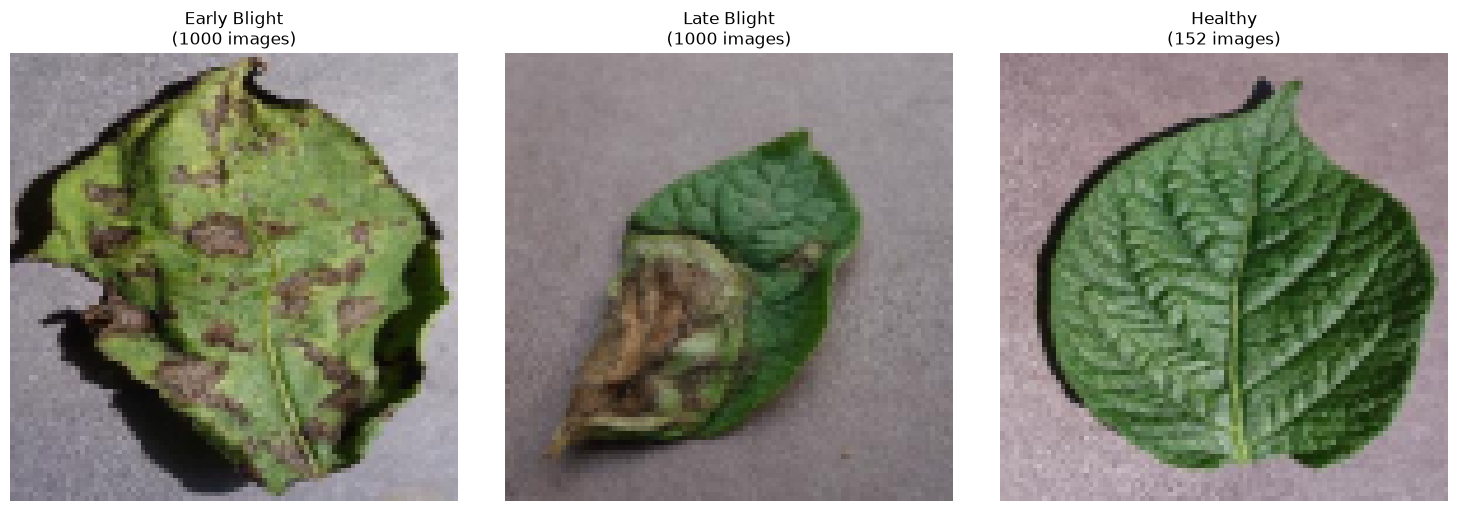


SPLITTING: 70% train, 15% val, 15% test
✅ Train: 1506
✅ Val:   323
✅ Test:  323

Class distribution:
  Early Blight    | Train:  700 | Val:  150 | Test:  150
  Late Blight     | Train:  700 | Val:  150 | Test:  150
  Healthy         | Train:  106 | Val:   23 | Test:   23

💾 Saved splits to data/processed/potato_splits.pkl


In [1]:
import os 
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from tqdm import tqdm 
import pickle 
 
# === CONFIGURATION === 
IMG_SIZE = 96 
DATA_DIR = "../data/kaggle_plantvillage/PlantVillage/" 
CACHE_FILE = "../data/processed/potato_dataset_cache.pkl" 
 
# ONLY these 3 classes - keep it small and focused 
CLASSES = [ 
    'Potato___Early_blight', 
    'Potato___Late_blight', 
    'Potato___healthy', 
] 
 
# Short display names (for plots and ESP32 output) 
CLASS_DISPLAY = { 
    'Potato___Early_blight': 'Early Blight', 
    'Potato___Late_blight':  'Late Blight', 
    'Potato___healthy':      'Healthy', 
} 
 
MAX_IMAGES_PER_CLASS = 1000  # Cap disease classes at 1000 
 
print("=" * 60) 
print("LOADING POTATO DATASET (3 CLASSES)") 
print("=" * 60) 
 
def load_potato_images(data_dir, classes, img_size=96, max_per_class=1000): 
    """ 
    Load ONLY the 3 potato classes from PlantVillage. 
     
    Why this function: 
    - Filters to just potato folders 
    - Handles class imbalance by capping at max_per_class 
    - Caches result so we don't re-read images 
    """ 
    if os.path.exists(CACHE_FILE): 
        print(f"📦 Loading from cache: {CACHE_FILE}") 
        with open(CACHE_FILE, 'rb') as f: 
            data = pickle.load(f) 
        return data['X'], data['y'], data['classes'] 
     
    X, y = [], [] 
    class_map = {cls: idx for idx, cls in enumerate(classes)} 
    class_counts = {} 
     
    for class_name in classes: 
        class_path = os.path.join(data_dir, class_name) 
         
        if not os.path.exists(class_path): 
            raise FileNotFoundError( 
                f"❌ {class_path} not found.\n" 
                f"   Check that PlantVillage was extracted correctly." 
            ) 
         
        # Get image list 
        image_files = [f for f in os.listdir(class_path) 
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))] 
         
        print(f"\n📂 {class_name}: {len(image_files)} images found") 
         
        # Cap at max_per_class 
        image_files = image_files[:max_per_class] 
        loaded = 0 
         
        for img_file in tqdm(image_files, desc=f"  Loading"): 
            img_path = os.path.join(class_path, img_file) 
            img = cv2.imread(img_path) 
             
            if img is None: 
                continue 
             
            # Resize to ESP32-friendly size 
            img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA) 
            # BGR → RGB (OpenCV default → standard) 
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
             
            X.append(img) 
            y.append(class_map[class_name]) 
            loaded += 1 
         
        class_counts[class_name] = loaded 
        print(f"  ✅ Loaded {loaded} images") 
     
    X = np.array(X, dtype=np.uint8) 
    y = np.array(y, dtype=np.int32) 
     
    # Save cache 
    os.makedirs(os.path.dirname(CACHE_FILE), exist_ok=True) 
    with open(CACHE_FILE, 'wb') as f: 
        pickle.dump({'X': X, 'y': y, 'classes': classes}, f) 
    print(f"\n💾 Cached to {CACHE_FILE}") 
     
    return X, y, classes 
 
 
# === LOAD === 
X, y, loaded_classes = load_potato_images(DATA_DIR, CLASSES, IMG_SIZE, MAX_IMAGES_PER_CLASS) 
 
print(f"\n{'='*60}") 
print(f"TOTAL: {len(X)} images, shape {X[0].shape}") 
print(f"{'='*60}") 
 
# === VISUALIZE === 
fig, axes = plt.subplots(1, 3, figsize=(15, 5)) 
for i, cls in enumerate(loaded_classes): 
    idx = np.where(y == i)[0] 
    axes[i].imshow(X[idx[0]]) 
    axes[i].set_title(f"{CLASS_DISPLAY[cls]}\n({len(idx)} images)", fontsize=12) 
    axes[i].axis('off') 
plt.tight_layout() 
os.makedirs('../docs', exist_ok=True) 
plt.savefig('../docs/potato_samples.png', dpi=100, bbox_inches='tight') 
plt.show() 
 
# === SPLIT (stratified to preserve balance) === 
print("\n" + "=" * 60) 
print("SPLITTING: 70% train, 15% val, 15% test") 
print("=" * 60) 
 
X_train, X_temp, y_train, y_temp = train_test_split( 
    X, y, test_size=0.30, random_state=42, stratify=y 
) 
X_val, X_test, y_val, y_test = train_test_split( 
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp 
) 
 
print(f"✅ Train: {len(X_train)}") 
print(f"✅ Val:   {len(X_val)}") 
print(f"✅ Test:  {len(X_test)}") 
 
# Show class distribution in each split 
print("\nClass distribution:") 
for i, cls in enumerate(loaded_classes): 
    print(f"  {CLASS_DISPLAY[cls]:15s} | " 
          f"Train: {np.sum(y_train==i):4d} | " 
          f"Val: {np.sum(y_val==i):4d} | " 
          f"Test: {np.sum(y_test==i):4d}") 
 
# === SAVE === 
splits = { 
    'X_train': X_train, 'y_train': y_train, 
    'X_val': X_val,     'y_val': y_val, 
    'X_test': X_test,   'y_test': y_test, 
    'classes': loaded_classes, 
    'class_display': CLASS_DISPLAY, 
} 
with open('../data/processed/potato_splits.pkl', 'wb') as f: 
    pickle.dump(splits, f) 
 
print(f"\n💾 Saved splits to data/processed/potato_splits.pkl")